# Project Checkpoint 1: Dataset Comparison, Selection, and EDA

**Aayush Upadhyay** | UIN: 436000751 | CSCE 676 Data Mining | Spring 2026

---

### Collaboration Declaration

1. **Collaborators**: None
2. **Web Sources**: Kaggle, Ergast Developer API docs, OpenF1 API docs, a couple GitHub repos for MotoGP data
3. **AI Tools**: Used Claude to help brainstorm what EDA to run, boilerplate plotting code, and cleaning up my writing
4. **Citations**: Ergast Developer API (http://ergast.com/mrd/), OpenF1 (https://openf1.org/), MarioJurado/MotoGP GitHub repo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path("data")

---

## (A) Identification of Candidate Datasets

I'm a big Formula 1 and motorcycle racing fan, so I wanted to find datasets in that space that would let me apply the techniques we've been learning in class (frequent itemsets, graph mining, PageRank, large-scale ML) while also giving me room to try something new beyond the course material.

I looked at a bunch of different sources, Kaggle, Zenodo, GitHub repos, and APIs like Ergast and OpenF1. Below are the three datasets I ended up considering.

---

### Dataset 1: Formula 1 World Championship (1950 - 2022)

| Field | Details |
|---|---|
| **Dataset name and source** | Formula 1 World Championship, sourced from the Ergast Developer API. Available on [Kaggle (rohanrao)](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020) and as a [GitHub mirror](https://github.com/rubenv/ergast-mrd) |
| **Course topic alignment** | Graph mining (build driver-constructor-circuit networks, run PageRank/centrality), frequent itemsets (mine pit stop strategy combos and podium co-occurrences), large-scale ML (predict race outcomes with ensemble methods like random forests and gradient boosted trees) |
| **Potential beyond-course techniques** | Survival analysis for modeling DNF (did not finish) events; time-series forecasting of lap time degradation across stints |
| **Dataset size and structure** | 14 relational CSV tables. Key sizes: ~515K lap time records, ~25K race results, ~8.9K pit stops, ~9.2K qualifying entries, 1079 races, 854 drivers, 211 constructors, 79 circuits. Spans 1950-2022. |
| **Data types** | Numeric IDs, categorical (driver names, constructor names, nationalities, circuit locations), temporal (dates, lap times in ms, pit stop durations), ordinal (grid positions, finishing positions, championship standings) |
| **Target variable(s)** | Multiple depending on the task: finishing position (supervised), DNF/status (binary classification), championship points (regression). For unsupervised tasks like frequent itemsets and graph mining, no explicit target. |
| **Licensing** | Creative Commons Attribution-NonCommercial-ShareAlike 3.0 (CC-BY-NC-SA 3.0). Free for academic/non-commercial use. |

---

### Dataset 2: OpenF1 Telemetry Data (2023 - present)

| Field | Details |
|---|---|
| **Dataset name and source** | OpenF1 real-time and historical telemetry data, available via the [OpenF1 API](https://openf1.org/) |
| **Course topic alignment** | Anomaly detection (flag unusual telemetry readings that precede mechanical failures), clustering (group drivers by driving style based on throttle/brake/speed profiles), large-scale ML (predict position changes from telemetry features) |
| **Potential beyond-course techniques** | Autoencoder-based anomaly detection on multivariate telemetry streams; this is a deep learning approach to finding unusual patterns that simpler threshold methods would miss |
| **Dataset size and structure** | 18 API endpoints. Car telemetry sampled at 3.7 Hz (speed, throttle, brake, RPM, gear) across 20 cars, ~60 laps per race. Roughly millions of rows per race weekend. Also includes lap times, pit stops, tire stints, weather, race control events, team radio. |
| **Data types** | Continuous numeric (speed in km/h, throttle %, brake binary, RPM), temporal (timestamps at sub-second resolution), categorical (driver codes, team names, tire compounds, flag types) |
| **Target variable(s)** | Anomaly labels (unsupervised, would need to derive), position deltas, lap time predictions |
| **Licensing** | Free for historical data access (2023+), non-commercial. Real-time data requires a paid subscription. |

---

### Dataset 3: MotoGP Historical Data (1949 - 2022)

| Field | Details |
|---|---|
| **Dataset name and source** | MotoGP historical race data, compiled from the official MotoGP API via Racing Mike's API. Available on [GitHub (amalsalilan)](https://github.com/amalsalilan/which-nation-excels-in-the-MotoGP) and [GitHub (MarioJurado)](https://github.com/MarioJurado/MotoGP) |
| **Course topic alignment** | Graph mining (rider-team-circuit networks, compute centrality and PageRank across competitive relationships), frequent itemsets (mine podium co-occurrence patterns by manufacturer and nationality) |
| **Potential beyond-course techniques** | Network embedding via node2vec on the rider-team rivalry graph, learning vector representations of riders based on their competitive relationships |
| **Dataset size and structure** | CSV tables covering races, results, riders, constructors, circuits, championships, and world standings across MotoGP, Moto2, and Moto3 categories. 70+ years of data. Smaller than the F1 dataset since fewer data points per race (no lap times or pit stops in the public data). |
| **Data types** | Numeric IDs, categorical (rider names, nationalities, team/constructor names), temporal (race dates, season years), ordinal (finishing positions, championship standings, points) |
| **Target variable(s)** | Championship standings (regression), podium finishes (classification). Mostly unsupervised for graph/itemset tasks. |
| **Licensing** | Publicly available, scraped from the official MotoGP API. No explicit license listed on the GitHub repos, but the data is factual race results (not copyrightable content). |

---

## (B) Comparative Analysis of Datasets

Here I compare the three datasets across the five required dimensions. The goal is to figure out which one gives me the best balance of course technique support, interesting beyond-course work, and practical feasibility.

| Dimension | F1 World Championship (1950-2022) | OpenF1 Telemetry (2023+) | MotoGP Historical (1949-2022) |
|---|---|---|---|
| **Supported data mining tasks** | Frequent itemsets (pit strategy combos, podium co-occurrence), graph mining with PageRank/centrality (driver-constructor-circuit networks), large-scale ML with ensembles (race outcome prediction), survival analysis for DNF prediction (beyond course) | Anomaly detection on telemetry streams (course), clustering of driving styles (course), autoencoder-based anomaly detection (beyond course) | Graph mining on rider-team networks (course), frequent itemsets on podium patterns (course), node2vec network embeddings (beyond course) |
| **Data quality issues** | Pretty clean overall since Ergast is well-maintained and widely used. Some missing lap times for older races (pre-1996). Pit stop data only available from 2012 onward. A few `\N` placeholders for missing values in qualifying times and fastest laps. Sprint results are sparse (only since 2021). | API returns clean structured JSON but you have to deal with rate limits and assembling data across many requests. Telemetry can have gaps if cars go off track or have sensor issues. Only covers 2023 onward so limited historical depth. Weather data can be spotty for some sessions. | Less standardized than F1 data since it's scraped from multiple sources. Some inconsistencies in rider names across eras. No lap-level data in the public version, just final results. The GitHub repos have different table structures that would need reconciling. |
| **Algorithmic feasibility** | Apriori is totally feasible here, the strategy combos per race are a natural basket-like structure and the dataset fits in memory easily. Graph construction is straightforward from the relational tables. Ensemble ML models will have no trouble with ~25K result rows. Survival analysis libraries (lifelines) handle this scale well. | The raw telemetry volume (millions of rows per weekend) would need careful sampling or aggregation to make algorithms work without excessive compute. Autoencoders would benefit from GPU access but aren't strictly necessary at sampled resolution. Clustering 20 drivers per race is very manageable. | Apriori works fine on this data, but the "baskets" are less natural than F1 pit strategies. Graph size is very manageable. The main limitation is that without lap-level data, some analyses (like temporal pattern mining) aren't possible. node2vec runs fine on graphs of this size. |
| **Bias considerations** | Survivorship bias: we only see data for drivers who made it to F1, which skews any analysis of "talent." Era bias is significant since the sport has changed dramatically (car tech, safety, number of races per season). Constructor dominance eras (like Mercedes 2014-2020) can skew pattern mining if not handled carefully. Western/European bias in early decades of the sport. | Recency bias since only 2023+ data exists. The telemetry is objective sensor data so less prone to human bias, but the interpretation of "anomalous" patterns requires domain assumptions. Also, the 2023+ era has specific regulation sets that don't generalize to other eras. | Similar era bias as F1. Strong European/Japanese manufacturer bias in the data. The sport has changed classes and rules many times, making cross-era comparisons tricky. Smaller grids in some eras versus others affect pattern frequencies. |
| **Ethical considerations** | Low risk overall. This is publicly available sports performance data, no personal or sensitive information. The main consideration is that building predictive models could theoretically be used for sports betting, but that's true of any sports dataset. The CC-BY-NC-SA license explicitly restricts commercial use. No power dynamic issues since these are public figures competing in a public sport. | Team radio transcripts could contain sensitive communications, but we'd only use telemetry numbers. Telemetry data could theoretically reveal proprietary team strategies, but OpenF1 only publishes what FIA already broadcasts publicly. No harm to individuals from analyzing car sensor data. | Same low-risk profile as F1. Public sports data about professional athletes. No privacy concerns. The scraped nature of the data means we should be respectful of the API provider's terms, but the data itself is factual results that are publicly known. |

---

## (C) Dataset Selection

**Selected dataset: Formula 1 World Championship (1950 - 2022)**

### Why I picked this one

The F1 World Championship dataset is the strongest choice for a few reasons:

- **It supports the most course techniques natively.** The 14 relational tables give me natural structures for frequent itemsets (pit stop strategy combinations as "baskets"), graph mining (driver-constructor-circuit relationships form a rich multi-relational graph for PageRank and community detection), and large-scale ML (predicting race outcomes with ensemble methods on ~25K results). That covers three major course topics in one dataset.

- **The beyond-course technique is practical and interesting.** Survival analysis for DNF prediction is a real thing teams care about, and Python's `lifelines` library makes it very doable without having to implement anything from scratch. I can also explore time-series forecasting on lap time degradation as a secondary beyond-course technique.

- **The data is clean and well-structured.** Ergast has been maintained for years and is one of the most widely used F1 data sources in the analytics community. The relational structure means joins are straightforward and the data types are consistent.

- **The size is right.** 515K lap times and 25K results is big enough to be interesting but small enough to run everything on a laptop without needing distributed computing or heavy GPU time.

### Trade-offs I'm accepting

- **No text data.** Unlike a Reddit/social media dataset, there's no natural language component here. If I wanted to do text mining or NLP, I'd need to supplement with an external source. But since text mining isn't the focus of my beyond-course technique, this is fine.

- **No real-time telemetry.** The OpenF1 dataset has richer per-lap sensor data (speed, throttle, brake at sub-second intervals), which would be cool for anomaly detection. But the added complexity of API data collection and the limited time range (2023+) make it less practical for this project.

- **Historical data cuts off at 2022.** The Ergast mirror I'm using goes up to 2022. I could supplement with newer data from the jolpica-f1 API if needed later, but for checkpoint 1, what we have is more than enough.

---

## (D) Exploratory Data Analysis

Now for the actual data work. Going to load everything up, poke around at the shapes and types, see what's missing, and then look at distributions and patterns.

### D.1: Loading and Inspecting the Data

In [2]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

RACES_COLUMNS = [
    "raceId", "year", "round", "circuitId", "name", "date", "time", "url",
    "fp1_date", "fp1_time", "fp2_date", "fp2_time", "fp3_date", "fp3_time",
    "quali_date", "quali_time", "sprint_date", "sprint_time"
]

tables = {}
for f in csv_files:
    name = f.stem
    if name == "races":
        df = pd.read_csv(f, na_values=["\\N", ""], header=0, names=RACES_COLUMNS)
    else:
        df = pd.read_csv(f, na_values=["\\N", ""])
    for col in df.columns:
        if col.endswith("Id"):
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    tables[name] = df

summary_rows = []
for name, df in tables.items():
    summary_rows.append({
        "Table": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Column Names": ", ".join(df.columns[:8]) + ("..." if len(df.columns) > 8 else ""),
        "Missing Values": df.isna().sum().sum(),
        "Missing %": f"{df.isna().sum().sum() / df.size * 100:.1f}%"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Table,Rows,Columns,Column Names,Missing Values,Missing %
0,circuits,79,9,"circuitId, circuitRef, name, location, country...",2,0.3%
1,constructor_results,11960,5,"constructorResultsId, raceId, constructorId, p...",11943,20.0%
2,constructor_standings,12721,7,"constructorStandingsId, raceId, constructorId,...",0,0.0%
3,constructors,211,5,"constructorId, constructorRef, name, nationali...",0,0.0%
4,driver_standings,33435,7,"driverStandingsId, raceId, driverId, points, p...",0,0.0%
5,drivers,854,9,"driverId, driverRef, number, code, forename, s...",1560,20.3%
6,lap_times,515715,6,"raceId, driverId, lap, position, time, millise...",0,0.0%
7,pit_stops,8887,7,"raceId, driverId, stop, lap, time, duration, m...",0,0.0%
8,qualifying,9155,9,"qualifyId, raceId, driverId, constructorId, nu...",10622,12.9%
9,races,1079,18,"raceId, year, round, circuitId, name, date, ti...",11257,58.0%


Quick look at the main tables we'll use most heavily: `results`, `races`, `drivers`, `constructors`, `lap_times`, and `pit_stops`.

In [3]:
results = tables["results"]
races = tables["races"]
drivers = tables["drivers"]
constructors = tables["constructors"]
lap_times = tables["lap_times"]
pit_stops = tables["pit_stops"]
circuits = tables["circuits"]
qualifying = tables["qualifying"]
status = tables["status"]
driver_standings = tables["driver_standings"]
constructor_standings = tables["constructor_standings"]

print("results.csv sample:")
display(results.head(3))
print("\nraces.csv sample:")
display(races.head(3))
print("\ndrivers.csv sample:")
display(drivers.head(3))
print("\npit_stops.csv sample:")
display(pit_stops.head(3))
print("\nlap_times.csv sample:")
display(lap_times.head(3))

results.csv sample:


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1



races.csv sample:


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



drivers.csv sample:


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg



pit_stops.csv sample:


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426



lap_times.csv sample:


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713


### D.2: Data Cleaning and Quality Assessment

Before doing anything real I want to see what's missing. Ergast uses `\N` for nulls which I already mapped to NaN during loading. Lets see which columns in the results table have the most gaps.

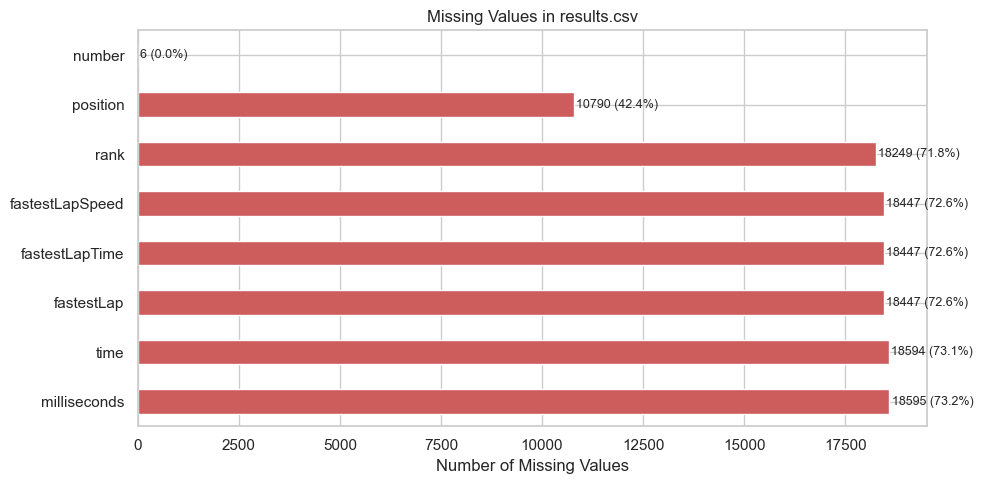

Total rows in results: 25420
Rows with a recorded finishing position: 14630
Rows where driver did NOT finish (position is NaN): 10790


In [4]:
missing_by_col = results.isna().sum()
missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
missing_by_col.plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values in results.csv")
for i, v in enumerate(missing_by_col):
    ax.text(v + 50, i, f"{v} ({v/len(results)*100:.1f}%)", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Total rows in results: {len(results)}")
print(f"Rows with a recorded finishing position: {results['position'].notna().sum()}")
print(f"Rows where driver did NOT finish (position is NaN): {results['position'].isna().sum()}")

So `position` being NaN just means the driver DNF'd (didn't finish). That's not actually missing data, it's meaningful. The `positionOrder` column has a number for everyone though, so I'll use that instead for most stuff. Same deal with `milliseconds` being null for DNFs (no finishing time if you didn't finish) and `fastestLap`/`rank`/`fastestLapTime`/`fastestLapSpeed` being empty for older races that didn't track that.

Not a data quality issue, just something to be aware of. Let me also check what years the lap times and pit stops cover since I know those aren't available for the full history.

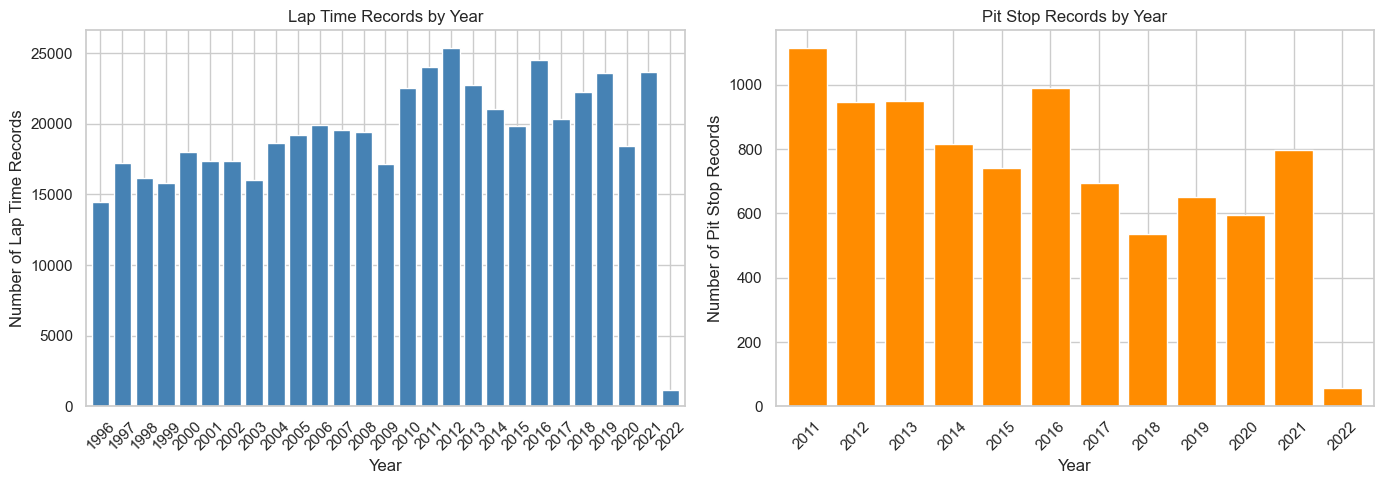

Lap times available from 1996 to 2022
Pit stops available from 2011 to 2022


In [5]:
lap_times_with_year = lap_times.merge(races[["raceId", "year"]], on="raceId")
pit_stops_with_year = pit_stops.merge(races[["raceId", "year"]], on="raceId")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lap_counts_by_year = lap_times_with_year.groupby("year").size()
lap_counts_by_year.plot(kind="bar", ax=axes[0], color="steelblue", width=0.8)
axes[0].set_title("Lap Time Records by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Lap Time Records")
axes[0].tick_params(axis='x', rotation=45)

pit_counts_by_year = pit_stops_with_year.groupby("year").size()
pit_counts_by_year.plot(kind="bar", ax=axes[1], color="darkorange", width=0.8)
axes[1].set_title("Pit Stop Records by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Pit Stop Records")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Lap times available from {lap_times_with_year['year'].min()} to {lap_times_with_year['year'].max()}")
print(f"Pit stops available from {pit_stops_with_year['year'].min()} to {pit_stops_with_year['year'].max()}")

Ok so lap times start around 1996 and pit stops from 2012. Anything involving those tables needs to be scoped to the right year range. For full-history stuff (graph mining, podium patterns), the complete 1950-2022 results are fine. Pit stop strategy mining will be 2012-2022 only.

### D.3: Races Per Season and Grid Size Over Time

F1 has grown a lot since 1950. Worth looking at how the calendar and grid sizes have evolved since that affects how we interpret pattern frequencies later.

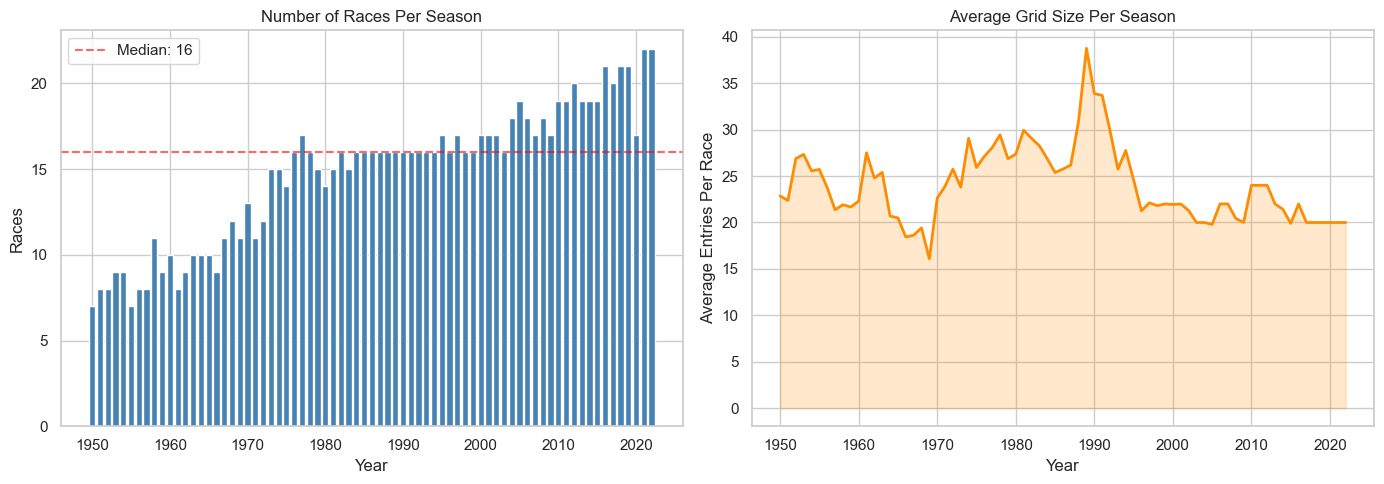

Season range: 1950 to 2022
Total races in dataset: 1079
Races per season: min=7, max=22, median=16


In [6]:
races_per_year = races.groupby("year").size().reset_index(name="num_races")

results_with_year = results.merge(races[["raceId", "year"]], on="raceId")
entries_per_race = results_with_year.groupby(["year", "raceId"]).size().reset_index(name="grid_size")
avg_grid = entries_per_race.groupby("year")["grid_size"].mean().reset_index(name="avg_grid_size")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(races_per_year["year"], races_per_year["num_races"], color="steelblue")
axes[0].set_title("Number of Races Per Season")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Races")
axes[0].axhline(y=races_per_year["num_races"].median(), color="red", linestyle="--", alpha=0.6, label=f'Median: {races_per_year["num_races"].median():.0f}')
axes[0].legend()

axes[1].plot(avg_grid["year"], avg_grid["avg_grid_size"], color="darkorange", linewidth=2)
axes[1].fill_between(avg_grid["year"], avg_grid["avg_grid_size"], alpha=0.2, color="darkorange")
axes[1].set_title("Average Grid Size Per Season")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Entries Per Race")

plt.tight_layout()
plt.show()

print(f"Season range: {races['year'].min()} to {races['year'].max()}")
print(f"Total races in dataset: {len(races)}")
print(f"Races per season: min={races_per_year['num_races'].min()}, max={races_per_year['num_races'].max()}, median={races_per_year['num_races'].median():.0f}")

### D.4: Top Drivers and Constructors by Wins

This matters for the itemset mining later. If Hamilton and Schumacher hog most of the wins, patterns involving them will have way higher support than midfield patterns. Need to see how concentrated the wins are.

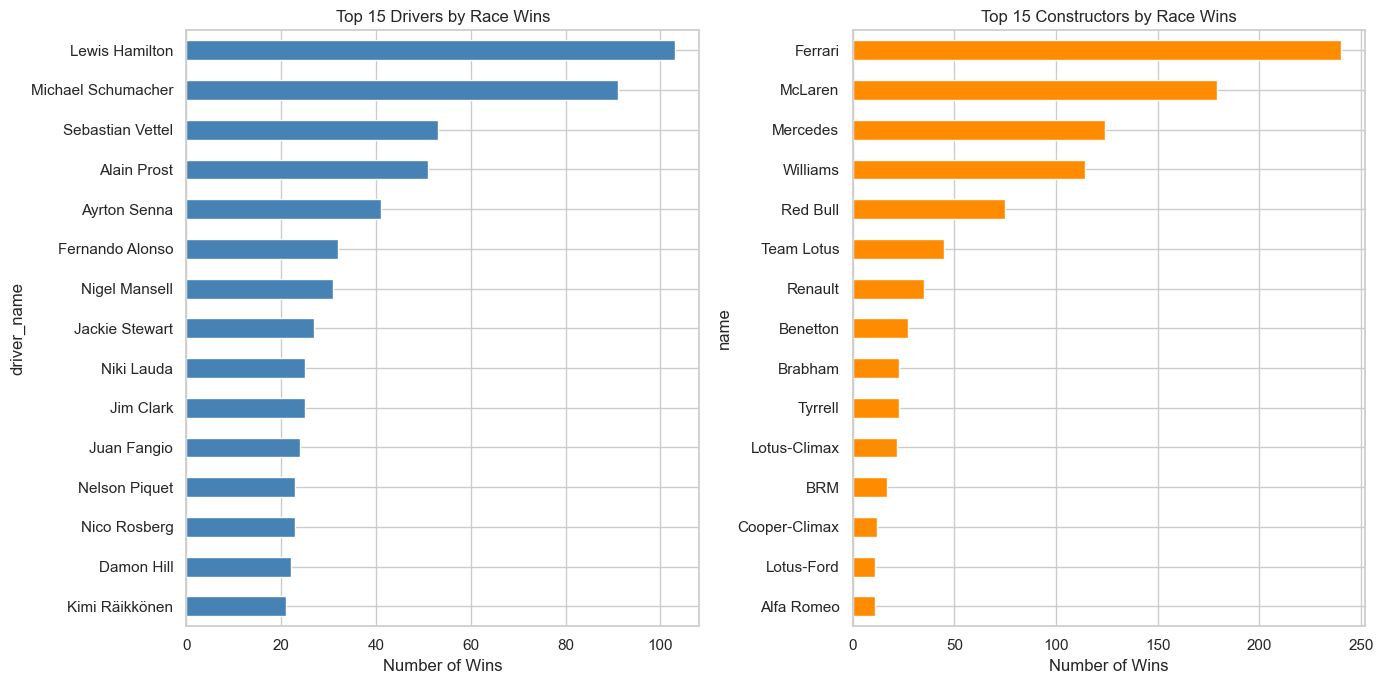

Top 5 drivers account for 339 out of 1058 total races (32.0% of all wins)
Top 5 constructors account for 732 out of 1058 total races (69.2% of all wins)


In [7]:
wins = results[results["positionOrder"] == 1].copy()
wins = wins.merge(drivers[["driverId", "forename", "surname"]], on="driverId")
wins["driver_name"] = wins["forename"] + " " + wins["surname"]
wins = wins.merge(constructors[["constructorId", "name"]], on="constructorId")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

top_drivers = wins["driver_name"].value_counts().head(15)
top_drivers.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 Drivers by Race Wins")
axes[0].set_xlabel("Number of Wins")
axes[0].invert_yaxis()

top_constructors = wins["name"].value_counts().head(15)
top_constructors.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Top 15 Constructors by Race Wins")
axes[1].set_xlabel("Number of Wins")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

total_races = results["raceId"].nunique()
top5_driver_wins = top_drivers.head(5).sum()
print(f"Top 5 drivers account for {top5_driver_wins} out of {total_races} total races ({top5_driver_wins/total_races*100:.1f}% of all wins)")

top5_constructor_wins = top_constructors.head(5).sum()
print(f"Top 5 constructors account for {top5_constructor_wins} out of {total_races} total races ({top5_constructor_wins/total_races*100:.1f}% of all wins)")

### D.5: Grid Position vs. Finishing Position

Classic F1 question, how important is qualifying? Looking at this as a heatmap. Also relevant for the ML task since grid position is probably a strong predictor.

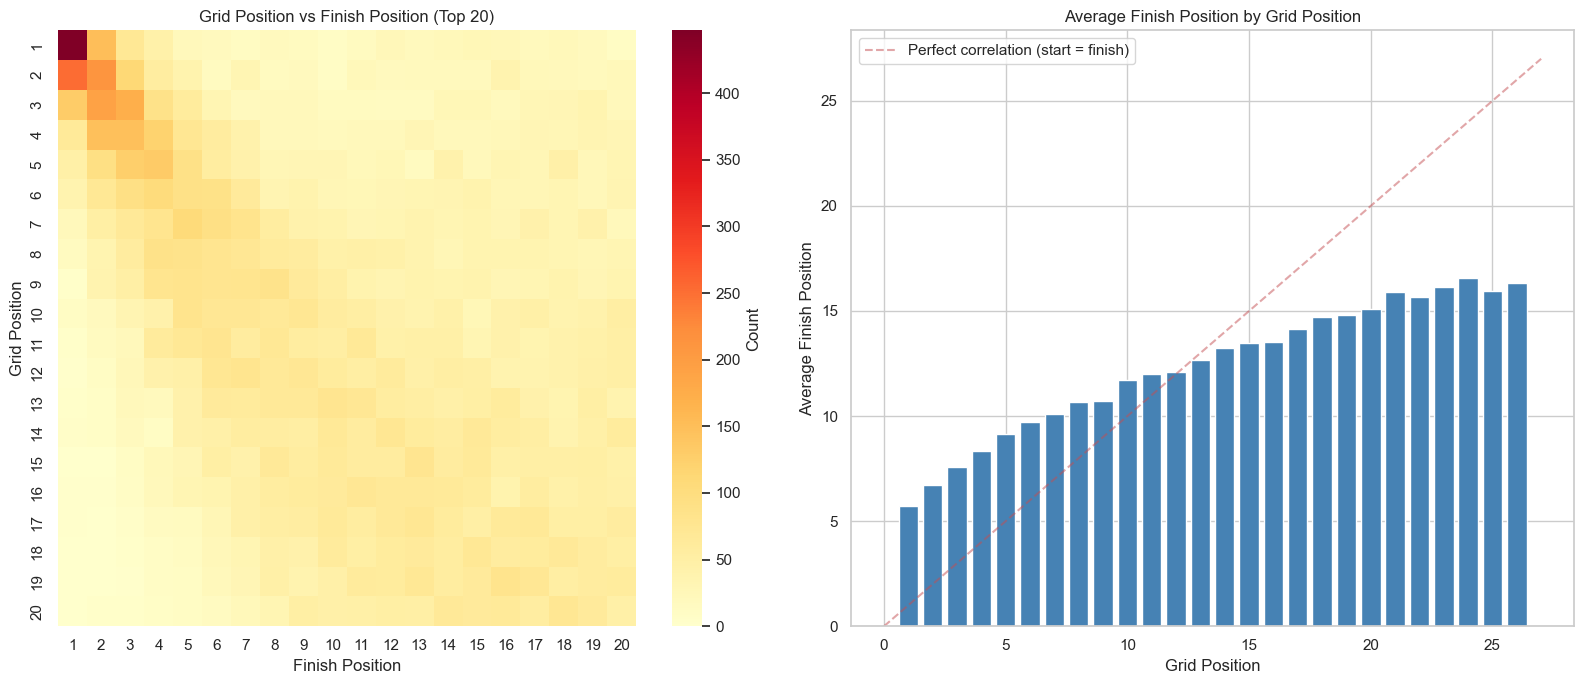

Pole position to win conversion rate: 447/1069 = 41.8%


In [8]:
grid_vs_finish = results[["grid", "positionOrder"]].copy()
grid_vs_finish = grid_vs_finish[(grid_vs_finish["grid"] > 0) & (grid_vs_finish["grid"] <= 26)]
grid_vs_finish = grid_vs_finish[grid_vs_finish["positionOrder"] <= 26]

cross = pd.crosstab(grid_vs_finish["grid"], grid_vs_finish["positionOrder"])
cross = cross.reindex(index=range(1, 27), columns=range(1, 27), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(cross.iloc[:20, :20], cmap="YlOrRd", ax=axes[0], cbar_kws={"label": "Count"})
axes[0].set_title("Grid Position vs Finish Position (Top 20)")
axes[0].set_xlabel("Finish Position")
axes[0].set_ylabel("Grid Position")

avg_finish_by_grid = grid_vs_finish.groupby("grid")["positionOrder"].mean()
axes[1].bar(avg_finish_by_grid.index, avg_finish_by_grid.values, color="steelblue")
axes[1].plot([0, 27], [0, 27], "r--", alpha=0.5, label="Perfect correlation (start = finish)")
axes[1].set_title("Average Finish Position by Grid Position")
axes[1].set_xlabel("Grid Position")
axes[1].set_ylabel("Average Finish Position")
axes[1].legend()

plt.tight_layout()
plt.show()

pole_wins = results[(results["grid"] == 1) & (results["positionOrder"] == 1)]
print(f"Pole position to win conversion rate: {len(pole_wins)}/{results[results['grid']==1].shape[0]} = {len(pole_wins)/results[results['grid']==1].shape[0]*100:.1f}%")

The diagonal in the heatmap is bright, which is what you'd expect: where you start is highly correlated with where you finish. But there's enough off-diagonal noise especially in the midfield that strategy and race pace still matter. Good sign for the itemset and ML stuff.

### D.6: DNF Analysis and Race Status Distribution

DNFs are a big part of F1, especially historically. Understanding the causes and trends here is key for the survival analysis I want to do as the beyond-course technique.

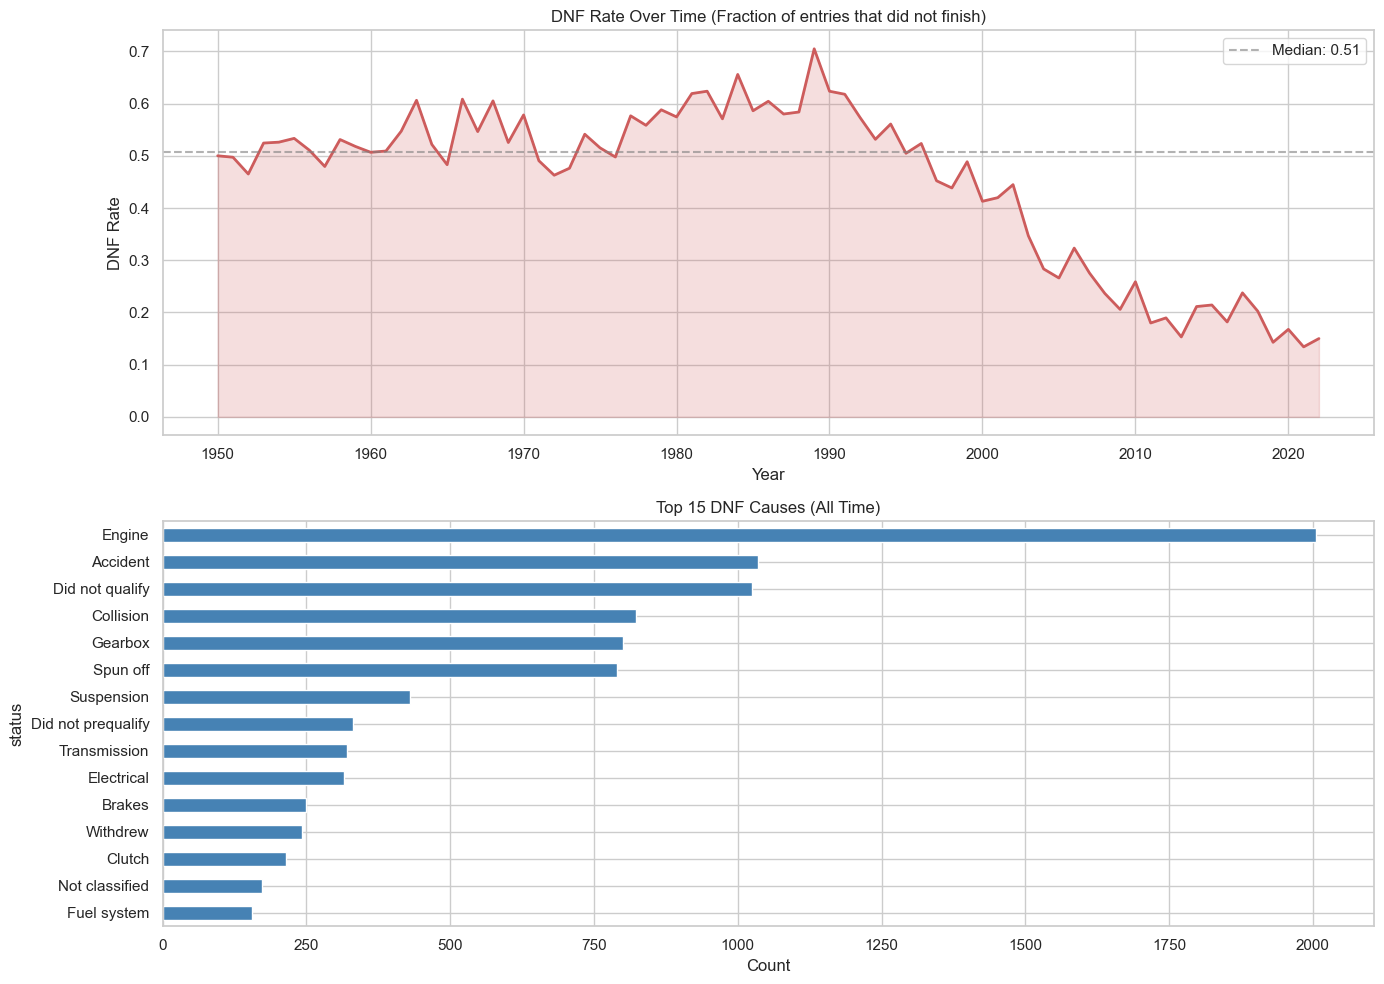

Overall DNF rate: 44.9%
DNF rate in 1950s: 50.9%
DNF rate in 2010s: 19.7%


In [9]:
results_status = results.merge(status, on="statusId")
results_status = results_status.merge(races[["raceId", "year"]], on="raceId")

results_status["finished"] = results_status["status"].str.contains("Finished|\\+", regex=True, na=False)

dnf_rate_by_year = results_status.groupby("year")["finished"].apply(lambda x: 1 - x.mean()).reset_index(name="dnf_rate")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(dnf_rate_by_year["year"], dnf_rate_by_year["dnf_rate"], color="indianred", linewidth=2)
axes[0].fill_between(dnf_rate_by_year["year"], dnf_rate_by_year["dnf_rate"], alpha=0.2, color="indianred")
axes[0].set_title("DNF Rate Over Time (Fraction of entries that did not finish)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("DNF Rate")
axes[0].axhline(y=dnf_rate_by_year["dnf_rate"].median(), color="gray", linestyle="--", alpha=0.6, label=f'Median: {dnf_rate_by_year["dnf_rate"].median():.2f}')
axes[0].legend()

dnf_entries = results_status[~results_status["finished"]]
top_causes = dnf_entries["status"].value_counts().head(15)
top_causes.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Top 15 DNF Causes (All Time)")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Overall DNF rate: {(~results_status['finished']).mean()*100:.1f}%")
print(f"DNF rate in 1950s: {dnf_rate_by_year[dnf_rate_by_year['year'] < 1960]['dnf_rate'].mean()*100:.1f}%")
print(f"DNF rate in 2010s: {dnf_rate_by_year[(dnf_rate_by_year['year'] >= 2010) & (dnf_rate_by_year['year'] < 2020)]['dnf_rate'].mean()*100:.1f}%")

Huge drop in DNF rates over the decades. In the 50s-60s nearly half the field would retire. Now its more like 10-15%. Engine failures used to be the big killer but modern cars are way more reliable. That declining hazard rate is exactly what makes survival analysis interesting here, the risk of retirement has changed a ton depending on era, constructor, circuit, etc.

### D.7: Pit Stop Strategy Patterns (2012-2022)

Pit stop data is where frequent itemset mining gets interesting. Each race is basically a "basket" of strategy choices.

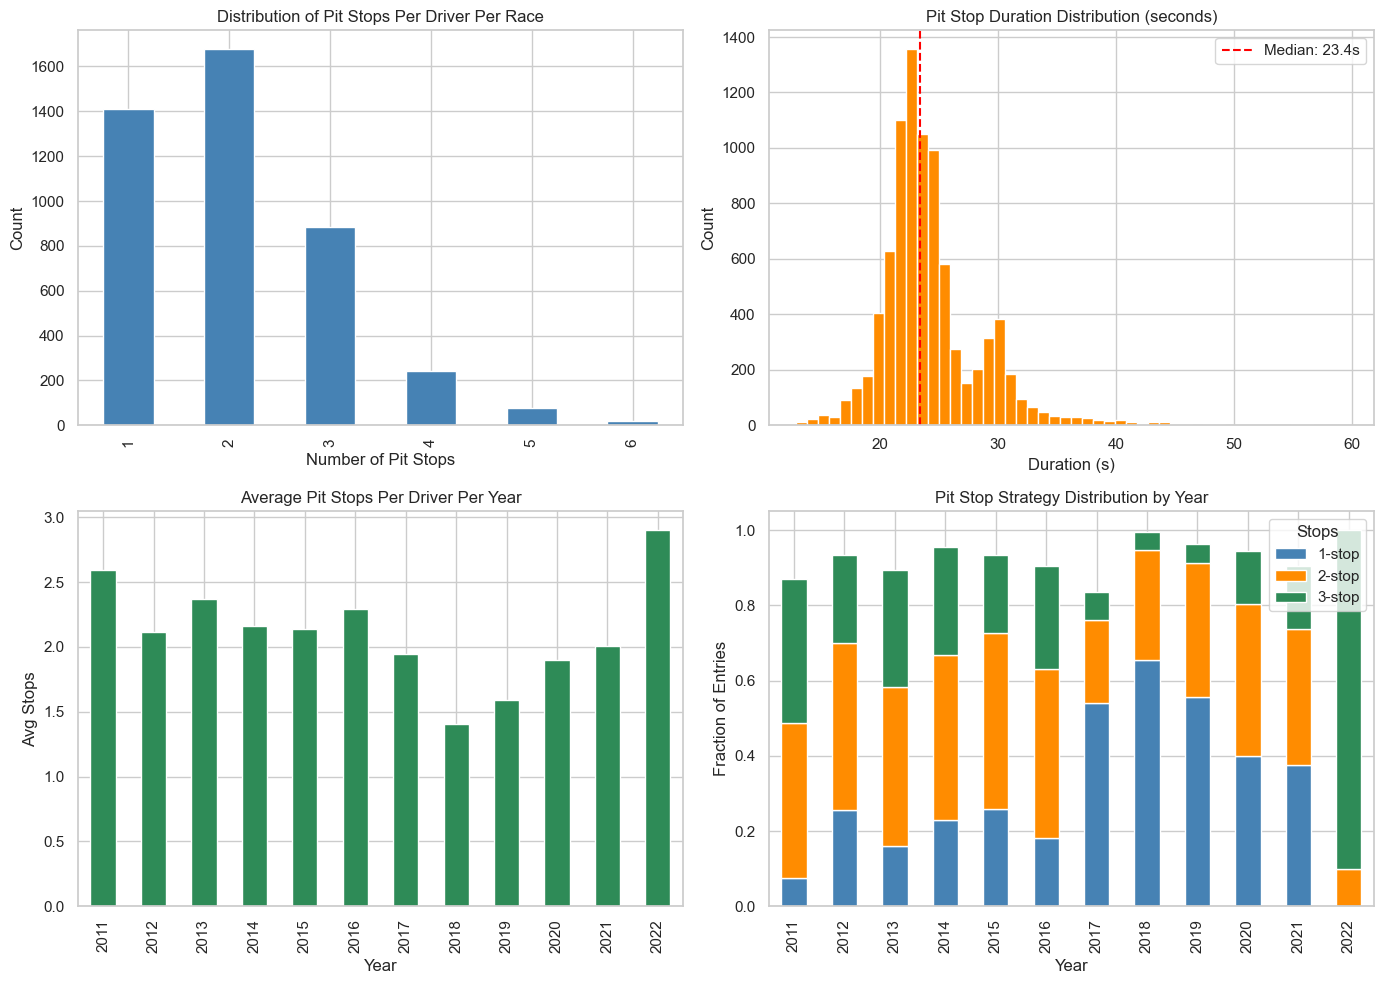

Median pit stop duration: 23.4s
Most common strategy: 2-stop
1-stop races: 1410 (32.7%)
2-stop races: 1677 (38.9%)


In [10]:
pit_with_race = pit_stops.merge(races[["raceId", "year", "name"]], on="raceId")

stops_per_driver_race = pit_with_race.groupby(["raceId", "driverId"]).agg(
    num_stops=("stop", "max"),
    total_pit_time_ms=("milliseconds", "sum")
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stops_per_driver_race["num_stops"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color="steelblue"
)
axes[0, 0].set_title("Distribution of Pit Stops Per Driver Per Race")
axes[0, 0].set_xlabel("Number of Pit Stops")
axes[0, 0].set_ylabel("Count")

pit_with_race["duration"] = pd.to_numeric(pit_with_race["duration"], errors="coerce")
valid_durations = pit_with_race["duration"].dropna()
valid_durations = valid_durations[(valid_durations > 0) & (valid_durations < 60)]
axes[0, 1].hist(valid_durations, bins=50, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Pit Stop Duration Distribution (seconds)")
axes[0, 1].set_xlabel("Duration (s)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].axvline(x=valid_durations.median(), color="red", linestyle="--", label=f"Median: {valid_durations.median():.1f}s")
axes[0, 1].legend()

avg_stops_by_year = stops_per_driver_race.merge(races[["raceId", "year"]], on="raceId")
yearly_avg = avg_stops_by_year.groupby("year")["num_stops"].mean()
yearly_avg.plot(kind="bar", ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Average Pit Stops Per Driver Per Year")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Avg Stops")

stop_strategy = stops_per_driver_race.groupby("raceId")["num_stops"].apply(
    lambda x: x.value_counts().to_dict()
).reset_index(name="strategy_dist")

strategy_counts = stops_per_driver_race.merge(races[["raceId", "year"]], on="raceId")
strategy_pivot = strategy_counts.groupby(["year", "num_stops"]).size().unstack(fill_value=0)
strategy_pivot_pct = strategy_pivot.div(strategy_pivot.sum(axis=1), axis=0)
strategy_pivot_pct[[1, 2, 3]].plot(kind="bar", stacked=True, ax=axes[1, 1], 
                                     color=["steelblue", "darkorange", "seagreen"])
axes[1, 1].set_title("Pit Stop Strategy Distribution by Year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Fraction of Entries")
axes[1, 1].legend(title="Stops", labels=["1-stop", "2-stop", "3-stop"])

plt.tight_layout()
plt.show()

print(f"Median pit stop duration: {valid_durations.median():.1f}s")
print(f"Most common strategy: {stops_per_driver_race['num_stops'].mode().values[0]}-stop")
print(f"1-stop races: {(stops_per_driver_race['num_stops']==1).sum()} ({(stops_per_driver_race['num_stops']==1).mean()*100:.1f}%)")
print(f"2-stop races: {(stops_per_driver_race['num_stops']==2).sum()} ({(stops_per_driver_race['num_stops']==2).mean()*100:.1f}%)")

Clear trend toward fewer stops recently. Makes sense, Pirelli tires have gotten more durable and teams have gotten better at managing them. The 1-stop has become the default. For itemset mining I'm thinking of framing each race as a transaction with items like (driver, num_stops, stop_lap_window, finish_bucket) and then looking for associations between strategy choices and outcomes.

### D.8: Lap Time Distributions and Degradation

Looking at how lap times behave within races. This is the time-series angle, tire degradation patterns within stints.

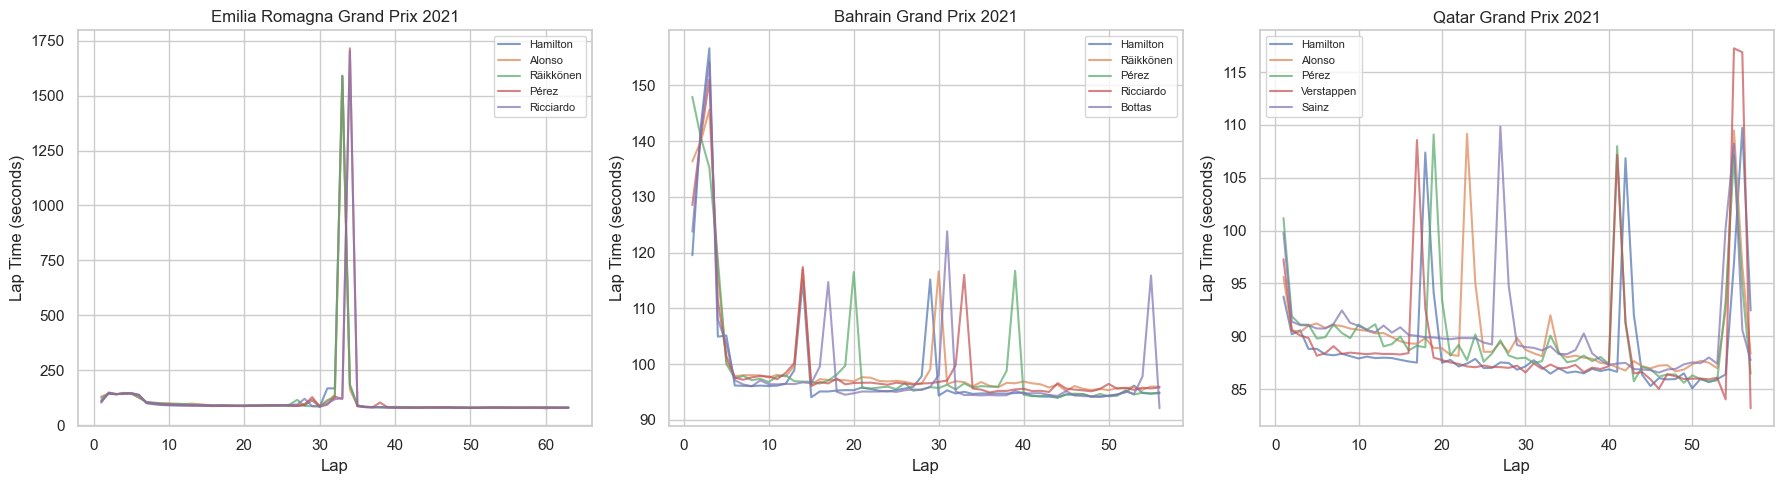

Overall lap time stats (in seconds):
  Mean: 95.6s
  Median: 90.7s
  Std: 73.8s


In [11]:
sample_races = races[(races["year"] == 2021)].head(3)
sample_race_ids = sample_races["raceId"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, race_id in enumerate(sample_race_ids):
    race_laps = lap_times[lap_times["raceId"] == race_id].copy()
    race_name = races[races["raceId"] == race_id]["name"].values[0]
    
    top_drivers = race_laps.groupby("driverId")["lap"].max().nlargest(5).index
    
    for driver_id in top_drivers:
        driver_laps = race_laps[race_laps["driverId"] == driver_id]
        driver_name = drivers[drivers["driverId"] == driver_id]["surname"].values[0]
        axes[idx].plot(driver_laps["lap"], driver_laps["milliseconds"] / 1000, 
                      label=driver_name, alpha=0.7, linewidth=1.5)
    
    axes[idx].set_title(f"{race_name} 2021")
    axes[idx].set_xlabel("Lap")
    axes[idx].set_ylabel("Lap Time (seconds)")
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

all_lap_ms = lap_times["milliseconds"].dropna()
print(f"Overall lap time stats (in seconds):")
print(f"  Mean: {all_lap_ms.mean()/1000:.1f}s")
print(f"  Median: {all_lap_ms.median()/1000:.1f}s")
print(f"  Std: {all_lap_ms.std()/1000:.1f}s")

You can clearly see the degradation within stints, lap times creep up then drop sharply after a pit stop. The big spikes are safety cars or outlaps. Pretty cool structure for time-series work.

### D.9: Driver-Constructor Network for Graph Mining

Building a quick look at the driver-constructor bipartite graph since graph mining is one of the main course techniques I want to use here.

Network stats:


  Nodes: 1005 (drivers + constructors)
  Edges: 2107 (driver-constructor relationships)
  Connected components: 15
  Density: 0.0042
  Largest component: 974 nodes (96.9% of total)


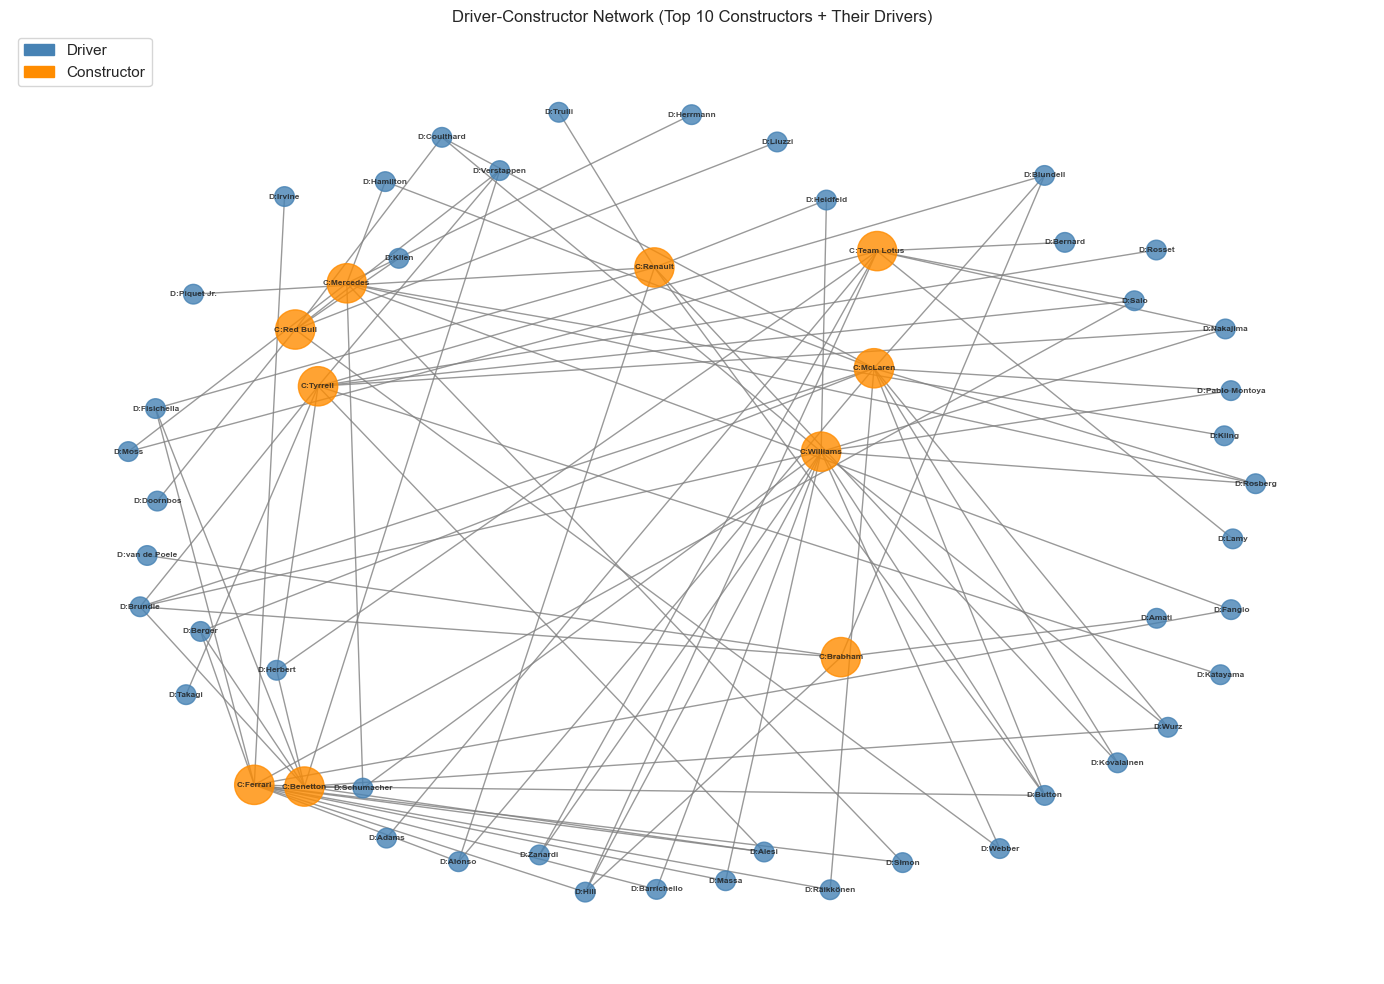

In [12]:
driver_constructor_pairs = results[["driverId", "constructorId"]].drop_duplicates()
driver_constructor_pairs = driver_constructor_pairs.merge(
    drivers[["driverId", "surname"]], on="driverId"
).merge(
    constructors[["constructorId", "name"]], on="constructorId"
)

G = nx.Graph()

for _, row in driver_constructor_pairs.iterrows():
    d_node = f"D:{row['surname']}"
    c_node = f"C:{row['name']}"
    G.add_node(d_node, type="driver")
    G.add_node(c_node, type="constructor")
    G.add_edge(d_node, c_node)

print(f"Network stats:")
print(f"  Nodes: {G.number_of_nodes()} (drivers + constructors)")
print(f"  Edges: {G.number_of_edges()} (driver-constructor relationships)")
print(f"  Connected components: {nx.number_connected_components(G)}")
print(f"  Density: {nx.density(G):.4f}")

largest_cc = max(nx.connected_components(G), key=len)
largest_subgraph = G.subgraph(largest_cc)
print(f"  Largest component: {len(largest_cc)} nodes ({len(largest_cc)/G.number_of_nodes()*100:.1f}% of total)")

top_constructors_list = wins["name"].value_counts().head(10).index.tolist()
important_nodes = set()
for c_name in top_constructors_list:
    c_node = f"C:{c_name}"
    if c_node in G:
        important_nodes.add(c_node)
        important_nodes.update(list(G.neighbors(c_node))[:5])

subgraph = G.subgraph(important_nodes)

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(subgraph, k=2, seed=42)

node_colors = ["darkorange" if subgraph.nodes[n].get("type") == "constructor" else "steelblue" 
               for n in subgraph.nodes()]
node_sizes = [800 if subgraph.nodes[n].get("type") == "constructor" else 200 
              for n in subgraph.nodes()]

nx.draw(subgraph, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
        with_labels=True, font_size=6, edge_color="gray", alpha=0.8, font_weight="bold")

ax.set_title("Driver-Constructor Network (Top 10 Constructors + Their Drivers)")
import matplotlib.patches as mpatches
driver_patch = mpatches.Patch(color="steelblue", label="Driver")
constructor_patch = mpatches.Patch(color="darkorange", label="Constructor")
ax.legend(handles=[driver_patch, constructor_patch], loc="upper left")

plt.tight_layout()
plt.show()

Network is well-connected. The giant component has almost all the nodes so PageRank and community detection should work fine without worrying about disconnected islands. Constructors are natural hubs since they employ multiple drivers over the years.

Could also build a driver rivalry graph where edges connect drivers who raced each other, weighted by frequency. That's a different angle for PageRank.

### D.10: Sparsity Analysis for Frequent Itemsets

For itemset mining I need to know how sparse things are. If most driver/outcome combos rarely co-occur, support thresholds need to be low.

Total unique podium finishers in history: 208
Total races: 1058


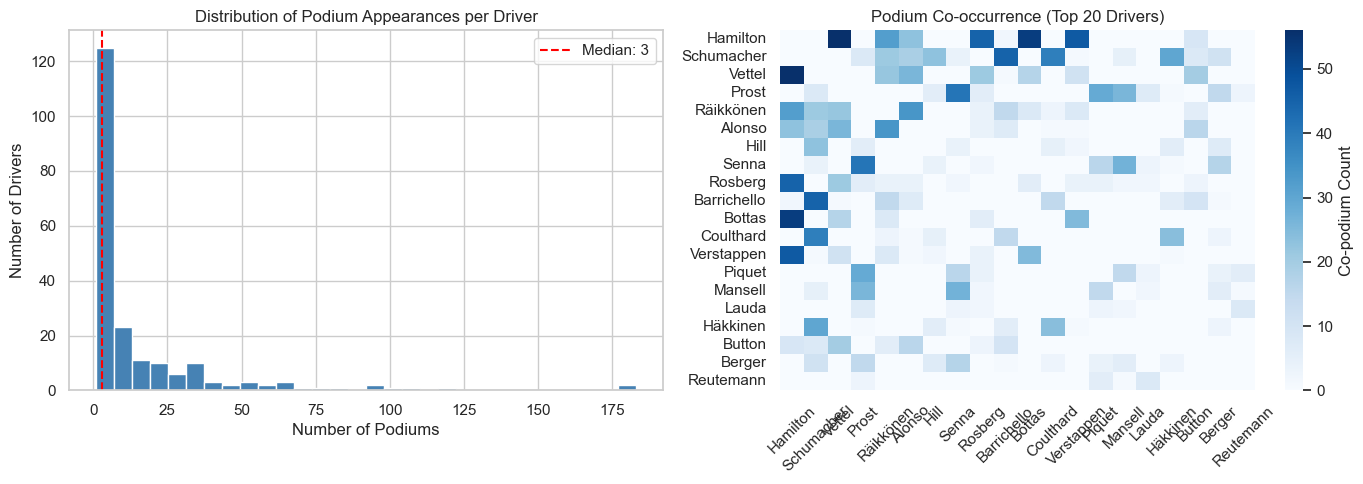

Sparsity of co-occurrence matrix (top 20 drivers): 56.84% sparse
Drivers with only 1 podium: 67 (32.2%)
Drivers with 10+ podiums: 72 (34.6%)


In [13]:
podium = results[results["positionOrder"] <= 3].copy()
podium = podium.merge(drivers[["driverId", "surname"]], on="driverId")

podium_per_race = podium.groupby("raceId")["surname"].apply(set).reset_index(name="podium_set")

all_podium_drivers = podium["surname"].unique()
print(f"Total unique podium finishers in history: {len(all_podium_drivers)}")
print(f"Total races: {len(podium_per_race)}")

podium_counts = podium["surname"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(podium_counts.values, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Podium Appearances per Driver")
axes[0].set_xlabel("Number of Podiums")
axes[0].set_ylabel("Number of Drivers")
axes[0].axvline(x=podium_counts.median(), color="red", linestyle="--", label=f"Median: {podium_counts.median():.0f}")
axes[0].legend()

top_podium = podium_counts.head(20).index.tolist()
cooccur = pd.DataFrame(0, index=top_podium, columns=top_podium)
for _, row in podium_per_race.iterrows():
    drivers_in_race = [d for d in row["podium_set"] if d in top_podium]
    for i, d1 in enumerate(drivers_in_race):
        for d2 in drivers_in_race[i+1:]:
            cooccur.loc[d1, d2] += 1
            cooccur.loc[d2, d1] += 1

sns.heatmap(cooccur, cmap="Blues", ax=axes[1], cbar_kws={"label": "Co-podium Count"})
axes[1].set_title("Podium Co-occurrence (Top 20 Drivers)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

total_cells = len(top_podium) * (len(top_podium) - 1) / 2
nonzero_pairs = (cooccur.values[np.triu_indices_from(cooccur.values, k=1)] > 0).sum()
print(f"Sparsity of co-occurrence matrix (top 20 drivers): {1 - nonzero_pairs / total_cells:.2%} sparse")
print(f"Drivers with only 1 podium: {(podium_counts == 1).sum()} ({(podium_counts == 1).mean()*100:.1f}%)")
print(f"Drivers with 10+ podiums: {(podium_counts >= 10).sum()} ({(podium_counts >= 10).mean()*100:.1f}%)")

Pretty sparse overall but you can see era-based clusters in the heatmap (Hamilton-Vettel-Rosberg in the 2010s, Schumacher-Hakkinen in the late 90s). So for itemset mining I'll probably need era-specific windows or low support thresholds.

The podium count distribution is super long-tailed too. Most drivers have 1-2 podiums, a handful of legends have 100+. Classic power-law territory. Something to keep in mind with support thresholds.

### D.11: Temporal Trends and Era Analysis

F1 has distinct "eras" based on regulation changes. Looking at some metrics over time to see if there are natural breakpoints worth using.

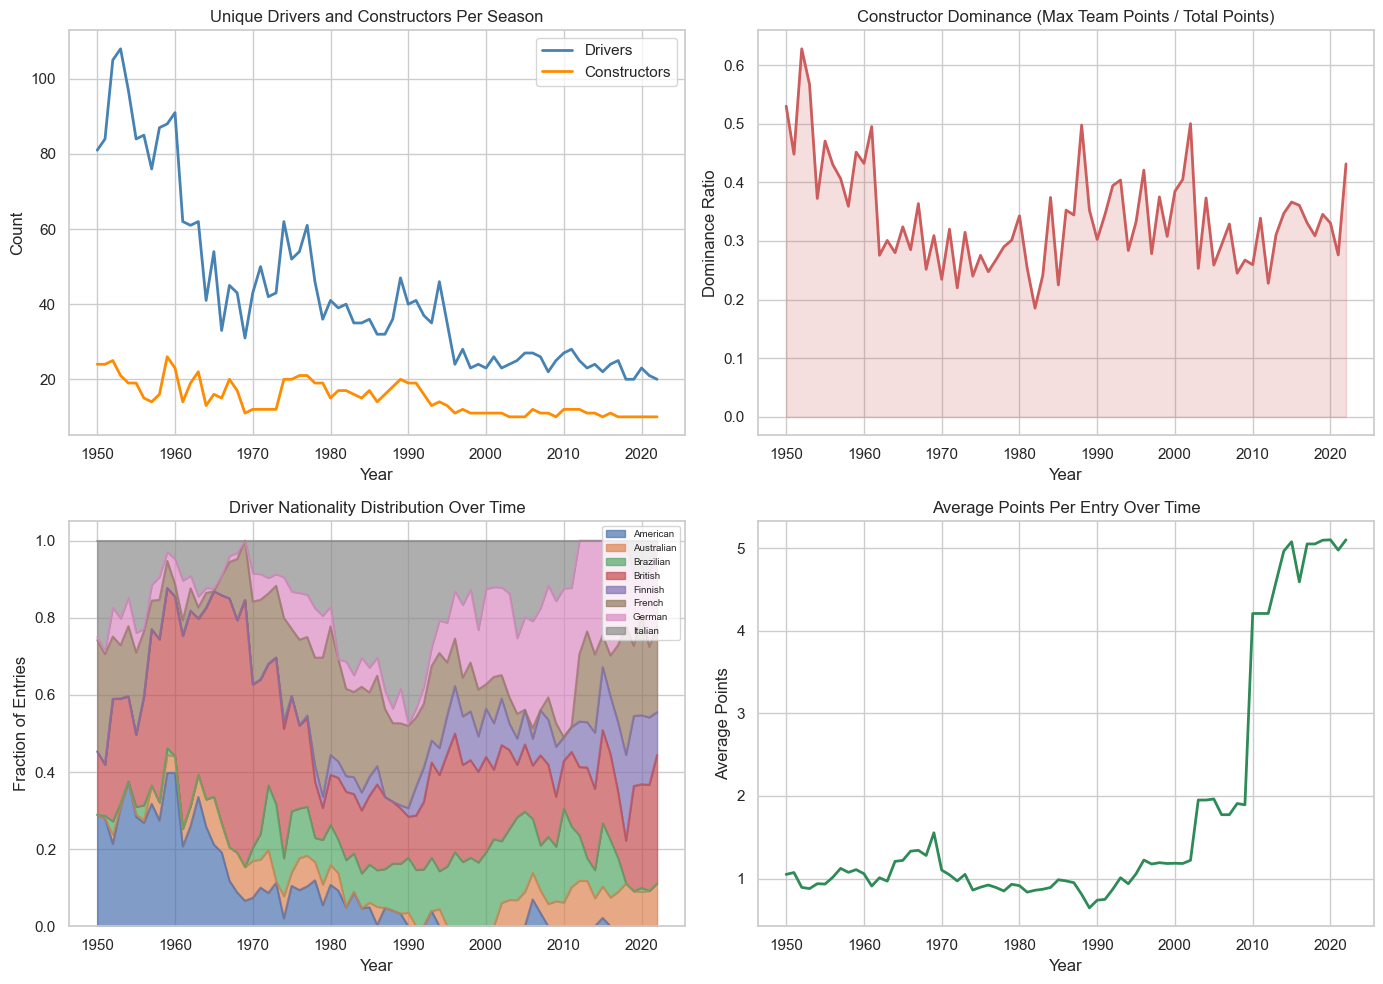

Key era transitions visible in the data:
  - Pre-1960: Large, variable grids with many DNFs
  - 1960s-80s: Stabilization of grid sizes, manufacturer dominance eras
  - 1990s-2000s: Peak constructor diversity, then consolidation
  - 2010s-2020s: Smaller stable grids (20 cars), points system changes inflate scores


In [14]:
results_full = results.merge(races[["raceId", "year"]], on="raceId")
results_full = results_full.merge(drivers[["driverId", "surname"]], on="driverId")
results_full = results_full.merge(constructors[["constructorId", "name"]], on="constructorId")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

unique_drivers_year = results_full.groupby("year")["driverId"].nunique()
unique_constructors_year = results_full.groupby("year")["constructorId"].nunique()

axes[0, 0].plot(unique_drivers_year.index, unique_drivers_year.values, color="steelblue", label="Drivers", linewidth=2)
axes[0, 0].plot(unique_constructors_year.index, unique_constructors_year.values, color="darkorange", label="Constructors", linewidth=2)
axes[0, 0].set_title("Unique Drivers and Constructors Per Season")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

points_per_year = results_full.groupby(["year", "name"])["points"].sum().reset_index()
max_points = points_per_year.groupby("year")["points"].max()
total_points = points_per_year.groupby("year")["points"].sum()
dominance = (max_points / total_points).dropna()
axes[0, 1].plot(dominance.index, dominance.values, color="indianred", linewidth=2)
axes[0, 1].fill_between(dominance.index, dominance.values, alpha=0.2, color="indianred")
axes[0, 1].set_title("Constructor Dominance (Max Team Points / Total Points)")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Dominance Ratio")

nationalities = results_full.merge(drivers[["driverId", "nationality"]], on="driverId", suffixes=("", "_dup"))
top_nats = nationalities["nationality"].value_counts().head(8).index
nat_over_time = nationalities[nationalities["nationality"].isin(top_nats)].groupby(
    ["year", "nationality"]
).size().unstack(fill_value=0)
nat_pct = nat_over_time.div(nat_over_time.sum(axis=1), axis=0)
nat_pct.plot(kind="area", stacked=True, ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_title("Driver Nationality Distribution Over Time")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Fraction of Entries")
axes[1, 0].legend(fontsize=7, loc="upper right")

avg_points = results_full.groupby("year")["points"].mean()
axes[1, 1].plot(avg_points.index, avg_points.values, color="seagreen", linewidth=2)
axes[1, 1].set_title("Average Points Per Entry Over Time")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Average Points")

plt.tight_layout()
plt.show()

print("Key era transitions visible in the data:")
print("  - Pre-1960: Large, variable grids with many DNFs")
print("  - 1960s-80s: Stabilization of grid sizes, manufacturer dominance eras")
print("  - 1990s-2000s: Peak constructor diversity, then consolidation")
print("  - 2010s-2020s: Smaller stable grids (20 cars), points system changes inflate scores")

### D.12: Summary Stats

Quick summary of the main tables before moving on.

In [15]:
print("DATASET OVERVIEW")
print(f"Seasons: {races['year'].min()}-{races['year'].max()} ({races['year'].nunique()} total)")
print(f"Races: {len(races)}")
print(f"Result entries: {len(results)}")
print(f"Drivers: {drivers['driverId'].nunique()}, Constructors: {constructors['constructorId'].nunique()}, Circuits: {circuits['circuitId'].nunique()}")
print(f"Lap times: {len(lap_times):,}, Pit stops: {len(pit_stops):,}, Qualifying: {len(qualifying):,}")
print()
print("NOTES:")
print(f"  Lap times: ~1996 onward")
print(f"  Pit stops: 2012 onward")
print(f"  DNF entries (no finishing position): {results['position'].isna().sum()}")
print(f"  Missing fastest lap data (older races): {results['fastestLapTime'].isna().sum()}")
print(f"  Duplicates in results: {results.duplicated().sum()}")
print()
display(results.select_dtypes(include=[np.number]).describe().round(2))

DATASET OVERVIEW
Seasons: 1950-2022 (73 total)
Races: 1079
Result entries: 25420
Drivers: 854, Constructors: 211, Circuits: 79
Lap times: 515,715, Pit stops: 8,887, Qualifying: 9,155

NOTES:
  Lap times: ~1996 onward
  Pit stops: 2012 onward
  DNF entries (no finishing position): 10790
  Missing fastest lap data (older races): 18447
  Duplicates in results: 0



,resultId,raceId,driverId,constructorId,number,grid,position,positionOrder,points,laps,milliseconds,fastestLap,rank,fastestLapSpeed,statusId
count,25420.0,25420.0,25420.0,25420.0,25414.00,25420.00,14630.00,25420.00,25420.00,25420.00,6825.00,6973.00,7171.00,6973.00,25420.0
mean,12711.27,522.27,254.23,47.85,17.67,11.20,7.91,12.92,1.82,45.86,6230368.10,42.38,10.44,202.92,17.66
std,7339.36,293.25,261.63,58.84,14.96,7.26,4.80,7.73,4.08,29.95,1685128.15,16.88,6.18,21.28,26.08
min,1.0,1.0,1.0,1.0,0.00,0.00,1.00,1.00,0.00,0.00,207071.00,2.00,0.00,89.54,1.0
25%,6355.75,289.0,56.0,6.0,7.00,5.00,4.00,6.00,0.00,21.00,5415575.00,32.00,5.00,192.68,1.0
50%,12710.5,506.0,160.0,25.0,15.00,11.00,7.00,12.00,0.00,52.00,5812941.00,45.00,10.00,204.19,11.0
75%,19065.25,769.0,356.0,58.0,23.00,17.00,11.00,19.00,2.00,66.00,6430420.00,54.00,16.00,215.87,14.0
max,25425.0,1074.0,855.0,214.0,208.00,34.00,33.00,39.00,50.00,200.00,15090540.00,85.00,24.00,257.32,139.0


### D.13: Sanity Checks

Quick checks to make sure the data makes sense before building anything on top of it.

In [16]:
winners = results[results["positionOrder"] == 1].groupby("raceId").size()
multi_winners = winners[winners > 1]
print(f"Races with multiple P1 finishers: {len(multi_winners)}")
for rid in multi_winners.index:
    yr = races[races["raceId"] == rid]["year"].values[0]
    nm = races[races["raceId"] == rid]["name"].values[0]
    print(f"  {nm} ({yr})")
print("^ these are shared-drive races from the 50s, two drivers got credit for the same car. makes sense.\n")

print(f"resultId unique? {results['resultId'].is_unique}")
print(f"All raceIds in results exist in races? {results['raceId'].isin(races['raceId']).all()}")
print(f"All driverIds in results exist in drivers? {results['driverId'].isin(drivers['driverId']).all()}")
print(f"All constructorIds valid? {results['constructorId'].isin(constructors['constructorId']).all()}")

pit_dur = pd.to_numeric(pit_stops["duration"], errors="coerce").dropna()
print(f"\nPit stop durations: min={pit_dur.min():.1f}s, max={pit_dur.max():.1f}s, median={pit_dur.median():.1f}s")
print(f"All positive and under 5 min? {(pit_dur > 0).all() and (pit_dur < 300).all()}")

lap_ms = lap_times["milliseconds"].dropna()
slow_laps = (lap_ms > 600000).sum()
print(f"\nLap times over 10 min: {slow_laps} ({slow_laps/len(lap_ms)*100:.2f}%)")
print(f"99.9th percentile: {lap_ms.quantile(0.999)/1000:.1f}s")
print("these are red flag / safety car laps where the clock keeps running, not bad data")

dupes = results.duplicated(subset=["raceId", "driverId"]).sum()
dup_rows = results[results.duplicated(subset=["raceId", "driverId"], keep=False)]
dup_years = dup_rows.merge(races[["raceId", "year"]], on="raceId")["year"]
print(f"\nDuplicate (raceId, driverId) pairs: {dupes}")
print(f"Year range: {int(dup_years.min())}-{int(dup_years.max())}")
print("all pre-1980, shared-drive era stuff where a driver switched cars mid-race")

print(f"\nAll checks look good, no unexpected issues.")

Races with multiple P1 finishers: 3
  British Grand Prix (1957)
  Argentine Grand Prix (1956)
  French Grand Prix (1951)
^ these are shared-drive races from the 50s, two drivers got credit for the same car. makes sense.

resultId unique? True
All raceIds in results exist in races? True
All driverIds in results exist in drivers? True
All constructorIds valid? True

Pit stop durations: min=12.9s, max=59.6s, median=23.4s
All positive and under 5 min? True

Lap times over 10 min: 443 (0.09%)
99.9th percentile: 275.7s
these are red flag / safety car laps where the clock keeps running, not bad data

Duplicate (raceId, driverId) pairs: 91
Year range: 1950-1978
all pre-1980, shared-drive era stuff where a driver switched cars mid-race

All checks look good, no unexpected issues.


---

## (E) Initial Insights and Direction

### Key Observations from EDA

1. **The data is dominated by a few drivers and constructors.** The top 5 drivers account for a disproportionate share of wins, and constructor dominance ebbs and flows with regulation changes. This heavy-tailed distribution means that frequent itemset mining will need careful support threshold tuning, or I should scope analyses to specific eras to avoid patterns being overwhelmed by Hamilton/Schumacher/Ferrari effects.

2. **Pit stop strategies have shifted heavily toward 1-stop races in recent years.** This is interesting because it means the "basket" of strategies per race has gotten less diverse over time. For frequent itemset mining, working with earlier years (2012-2017) might yield richer patterns than the more recent seasons where everyone does the same thing.

3. **DNF rates have dropped dramatically over the decades.** In the 1950s, nearly half the field would retire. By 2020, it's closer to 10%. This time-varying hazard rate is a natural fit for survival analysis, where I can model how the "risk" of retirement depends on factors like grid position, constructor, circuit type, and era.

4. **Grid position is a strong but imperfect predictor of finishing position.** Pole sitters win roughly 40% of the time, which means there's meaningful variance to model. The midfield positions (5-15) show a lot more shuffling, which is where pit stop strategy and race pace really matter.

5. **The driver-constructor network is well-connected.** The bipartite graph has a giant connected component covering most nodes. This makes it suitable for PageRank and community detection without worrying about disconnected subgraphs dominating the analysis.

### Hypotheses

- **H1:** High support thresholds in frequent itemset mining will only surface obvious patterns (top drivers win a lot). Lowering the threshold and restricting to era-specific windows will reveal more nuanced strategy-outcome associations.

- **H2:** Survival analysis will show that constructor reliability is a stronger predictor of DNF than driver skill, especially in earlier decades when mechanical failure was the dominant cause.

- **H3:** In the driver-constructor network, PageRank scores will correlate with championship success but also reveal "bridge" drivers who moved between teams and transferred competitive knowledge.

### Potential Research Questions

- **RQ1:** How do pit stop strategy patterns (number of stops, timing of stops) associate with race outcomes? Do these associations differ between circuits?

- **RQ2:** Can we predict DNF events using a survival model that accounts for driver, constructor, circuit, and era? What are the most significant risk factors?

- **RQ3:** In the driver-constructor network, which drivers have the highest centrality and what does that tell us about the flow of competitive advantage in F1?

- **RQ4:** Do the "community" structures detected in the driver-constructor network correspond to known F1 eras and alliances (e.g., the Ferrari driver pipeline, the Red Bull junior program)?

### Planned Techniques

| Technique | Course or Beyond | Application |
|---|---|---|
| Frequent Itemsets (Apriori) | Course (Week 2) | Mine pit stop strategy and outcome patterns |
| Association Rules | Course (Week 2) | Generate rules like {1-stop, pit lap 15-20} -> {top-5 finish} |
| Graph Mining / PageRank | Course (Weeks 3-4) | Rank drivers in the driver-constructor network |
| Community Detection | Course (Week 4) | Find clusters in the competitive network |
| Ensemble ML (Random Forest, GBT) | Course (Week 5) | Predict race outcomes from pre-race features |
| Survival Analysis | Beyond Course | Model DNF hazard rates with Cox proportional hazards |

---

## (F) GitHub Portfolio

**GitHub Repository:** [https://github.com/aaupadhy/formula1-datamining](https://github.com/aaupadhy/formula1-datamining)

The repository contains:
- `checkpoint1.ipynb` - This notebook
- `data/` - The F1 World Championship CSV dataset (from Ergast Developer API)
- `requirements.txt` - Python dependencies
- `README.md` - Project description and setup instructions